In [4]:
from google.colab import drive
import os
import shutil
import glob
import pickle
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image

# Mount Google Drive
drive.mount('/content/drive')

# Specify unzipped dataset folder path
DRIVE_FOLDER_PATH = '/content/drive/MyDrive/ai crop dataset'
LOCAL_DIR = '/content/unified_crop_dataset'

if not os.path.exists(DRIVE_FOLDER_PATH):
    raise FileNotFoundError(f"Cannot locate '{DRIVE_FOLDER_PATH}'. Please verify folder name.")

print("Drive connected successfully. Ready to process dataset.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive connected successfully. Ready to process dataset.


In [3]:
import os
import shutil
from concurrent.futures import ThreadPoolExecutor

os.makedirs(LOCAL_DIR, exist_ok=True)
TARGET_PREFIXES = ['Tomato', 'Maize']

# 1. Fast parallel copy for Tomato and Maize folders
def copy_crop_dir(folder_name):
    source = os.path.join(DRIVE_FOLDER_PATH, folder_name)
    dest = os.path.join(LOCAL_DIR, folder_name)
    if os.path.isdir(source) and any(folder_name.startswith(p) for p in TARGET_PREFIXES):
        if not os.path.exists(dest):
            # Fast system copy (bypasses Python overhead)
            os.system(f'cp -r "{source}" "{dest}"')
            print(f"Copied: {folder_name}")

print("Syncing Tomato & Maize folders...")
with ThreadPoolExecutor(max_workers=4) as executor:
    executor.map(copy_crop_dir, os.listdir(DRIVE_FOLDER_PATH))

# 2. Fast Rice folder processing
rice_dir = os.path.join(DRIVE_FOLDER_PATH, 'rice')
if os.path.exists(rice_dir):
    print("\nScanning and sorting Rice images using fast thread workers...")

    # Pre-create category directories
    for cat in ["Rice blast", "Rice bacterial blight", "Rice brown spot", "Rice healthy"]:
        os.makedirs(os.path.join(LOCAL_DIR, cat), exist_ok=True)

    # Use os.scandir/walk (much faster than glob over Drive)
    rice_tasks = []
    for root, _, files in os.walk(rice_dir):
        for file in files:
            lower_name = file.lower()
            if lower_name.endswith(('.jpg', '.jpeg', '.png')):
                if 'blast' in lower_name:
                    target_cls = "Rice blast"
                elif 'bacterial' in lower_name or 'blight' in lower_name:
                    target_cls = "Rice bacterial blight"
                elif 'brown' in lower_name or 'spot' in lower_name:
                    target_cls = "Rice brown spot"
                else:
                    target_cls = "Rice healthy"

                src_path = os.path.join(root, file)
                dst_path = os.path.join(LOCAL_DIR, target_cls, file)
                rice_tasks.append((src_path, dst_path))

    # Helper function to copy if not exists
    def copy_file_task(paths):
        s, d = paths
        if not os.path.exists(d):
            shutil.copyfile(s, d)

    # Copy files in parallel across 16 concurrent threads
    with ThreadPoolExecutor(max_workers=16) as executor:
        list(executor.map(copy_file_task, rice_tasks))

print("\n--- Verified Dataset Classes & Counts ---")
classes = sorted(os.listdir(LOCAL_DIR))
for c in classes:
    count = len(os.listdir(os.path.join(LOCAL_DIR, c)))
    print(f" • {c}: {count} images")

Syncing Tomato & Maize folders...

Scanning and sorting Rice images using fast thread workers...

--- Verified Dataset Classes & Counts ---
 • Maize fall armyworm: 285 images
 • Maize grasshoper: 673 images
 • Maize healthy: 208 images
 • Maize leaf beetle: 949 images
 • Maize leaf blight: 1006 images
 • Maize leaf spot: 1259 images
 • Maize streak virus: 979 images
 • Rice bacterial blight: 891 images
 • Rice blast: 1709 images
 • Rice brown spot: 1558 images
 • Rice healthy: 4523 images
 • Tomato healthy: 470 images
 • Tomato leaf blight: 1301 images
 • Tomato leaf curl: 518 images
 • Tomato septoria leaf spot: 2743 images
 • Tomato verticulium wilt: 773 images


In [5]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=LOCAL_DIR, transform=data_transforms)
class_names = dataset.classes
print(f"Total detected classes: {len(class_names)}")

# 80/20 train/validation split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)
print(f"Train samples: {len(train_set)} | Validation samples: {len(val_set)}")

Total detected classes: 16
Train samples: 15876 | Validation samples: 3969


In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
# Update classification head
model.classifier[1] = nn.Linear(model.last_channel, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

Using device: cuda:0
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 129MB/s]


In [9]:
from PIL import Image, ImageFile
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Allow PIL to handle truncated/partially broken image files
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 2. Scan and remove any 0-byte or unreadable corrupted files
print("Verifying all images in local dataset...")
corrupted_count = 0
for root, _, files in os.walk(LOCAL_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            file_path = os.path.join(root, f)
            try:
                # Check for 0-byte files
                if os.path.getsize(file_path) == 0:
                    os.remove(file_path)
                    corrupted_count += 1
                    continue
                # Verify image can be parsed
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                try:
                    os.remove(file_path)
                    corrupted_count += 1
                except Exception:
                    pass

print(f"Removed {corrupted_count} corrupted/unreadable images.")

# 3. Reload Dataset and Recreate DataLoader with num_workers=0
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=LOCAL_DIR, transform=data_transforms)
class_names = dataset.classes

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Setting num_workers=0 runs DataLoader in the main thread (avoids worker process crashes)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=0)

print(f"DataLoaders recreated successfully. Ready for training!")

Verifying all images in local dataset...
Removed 51 corrupted/unreadable images.
DataLoaders recreated successfully. Ready for training!


In [10]:
EPOCHS = 6

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_set)
    epoch_acc = running_corrects.double() / len(train_set)

    # Validation
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device)

            val_outputs = model(val_inputs)
            _, val_preds = torch.max(val_outputs, 1)
            val_corrects += torch.sum(val_preds == val_labels.data)

    val_acc = val_corrects.double() / len(val_set)
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

Epoch 1/6 -> Train Loss: 0.6826 | Train Acc: 76.46% | Val Acc: 86.64%
Epoch 2/6 -> Train Loss: 0.3667 | Train Acc: 86.29% | Val Acc: 87.88%
Epoch 3/6 -> Train Loss: 0.2949 | Train Acc: 88.71% | Val Acc: 88.99%
Epoch 4/6 -> Train Loss: 0.2551 | Train Acc: 90.57% | Val Acc: 88.58%
Epoch 5/6 -> Train Loss: 0.2181 | Train Acc: 91.47% | Val Acc: 89.90%
Epoch 6/6 -> Train Loss: 0.1920 | Train Acc: 92.99% | Val Acc: 89.64%


In [11]:
model.eval()

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Pick an image from the Rice blast folder to test
sample_img_path = glob.glob(os.path.join(LOCAL_DIR, 'Rice blast', '*'))[0]
sample_img = Image.open(sample_img_path).convert('RGB')
input_tensor = test_transform(sample_img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_prob, top_idx = torch.max(probabilities, 0)
    predicted_label = class_names[top_idx.item()]

print("\n--- Model Verification ---")
print(f"Sample Tested : {os.path.basename(sample_img_path)}")
print(f"Prediction    : {predicted_label}")
print(f"Confidence    : {top_prob.item() * 100:.2f}%")


--- Model Verification ---
Sample Tested : r6k_train_Blast_1092_jpg.rf.40e3dec7e986576428282b88392df6c6.jpg
Prediction    : Rice blast
Confidence    : 97.45%


In [12]:
model_payload = {
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'architecture': 'mobilenet_v2'
}

output_pkl_path = '/content/drive/MyDrive/crop_disease_model.pkl'

with open(output_pkl_path, 'wb') as f:
    pickle.dump(model_payload, f)

print(f"\nModel exported successfully to Google Drive:\n{output_pkl_path}")


Model exported successfully to Google Drive:
/content/drive/MyDrive/crop_disease_model.pkl


👉 Click 'Choose Files' below to upload a crop leaf image for testing:



Saving tomato.jpg to tomato (1).jpg


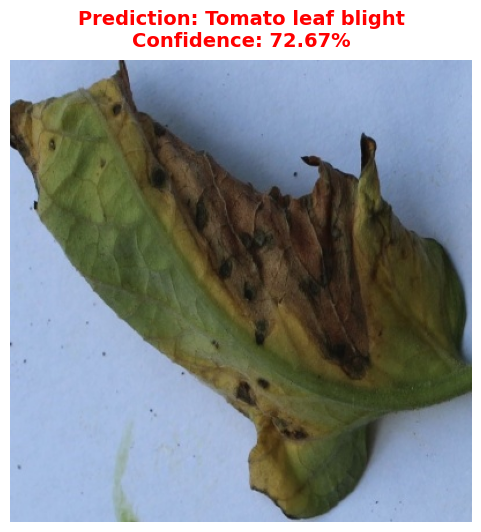


📁 File Tested : tomato (1).jpg
🎯 Diagnosis   : Tomato leaf blight
📊 Confidence  : 72.67%
Top Probability Breakdown:
  [1] Tomato leaf blight             : 72.67%
  [2] Tomato verticulium wilt        : 25.48%
  [3] Tomato septoria leaf spot      : 1.67%



In [15]:
import torch
from torchvision import transforms
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt
import io

# ==============================================================================
# 1. DEFINE PREPROCESSING TRANSFORM FOR INFERENCE
# ==============================================================================
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_single_image(image_bytes, filename="uploaded_image"):
    # Load and convert image to RGB
    img = Image.open(io.BytesIO(image_bytes)).convert('RGB')

    # Preprocess tensor and move to device
    input_tensor = inference_transform(img).unsqueeze(0).to(device)

    # Run forward pass
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)

    # Get top 3 predictions
    top_probs, top_indices = torch.topk(probabilities, k=min(3, len(class_names)))

    best_class = class_names[top_indices[0].item()]
    best_conf = top_probs[0].item() * 100

    # Plot image with results
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')

    # Color code: green if healthy, red if diseased
    title_color = 'green' if 'healthy' in best_class.lower() else 'red'
    plt.title(f"Prediction: {best_class}\nConfidence: {best_conf:.2f}%",
              fontsize=14, color=title_color, pad=10, fontweight='bold')
    plt.show()

    # Print detailed output in terminal format
    print("\n" + "="*50)
    print(f"📁 File Tested : {filename}")
    print(f"🎯 Diagnosis   : {best_class}")
    print(f"📊 Confidence  : {best_conf:.2f}%")
    print("="*50)
    print("Top Probability Breakdown:")
    for i in range(len(top_indices)):
        c_name = class_names[top_indices[i].item()]
        c_prob = top_probs[i].item() * 100
        print(f"  [{i+1}] {c_name.ljust(30)} : {c_prob:.2f}%")
    print("="*50 + "\n")

# ==============================================================================
# 2. FILE UPLOADER WIDGET
# ==============================================================================
print("👉 Click 'Choose Files' below to upload a crop leaf image for testing:\n")
uploaded = files.upload()

for filename, content in uploaded.items():
    predict_single_image(content, filename=filename)